### Librerie

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from iminuit import Minuit
from scipy.stats import norm

# Impostazioni grafiche per i plot
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

### Caricamento dati

In [21]:
# da mettere nome file
nome_file = "dati1.csv"  

df = pd.read_csv(nome_file, sep=";", decimal=",")

# stampa le colonne per controllo
print("Colonne nel file:\n", df.columns.tolist())


# inserire gli indici numerici corretti delle colonne
idx_x = 6          # Indice colonna posizione x [mm]
idx_v_netta = 8   # Indice colonna V_netta = V_dir - V_fondo
idx_sig_fondo = 10  # Indice colonna Errore sul fondo

# Estrazione dei dati (rimuovendo eventuali righe vuote)
dati = df.iloc[:, [idx_x, idx_v_netta, idx_sig_fondo]].dropna()

#creo array
x_raw = dati.iloc[:, 0].to_numpy(dtype=float)
y = dati.iloc[:, 1].to_numpy(dtype=float)
sigma_fondo = dati.iloc[:, 2].to_numpy(dtype=float) # errori V fondo

print(f"\nNumero di punti sperimentali caricati: {len(y)}")

Colonne nel file:
 ['x [mm]', 'x0 [mm]', 'V_dir [V]', 'V_fondo1 [V]', 'V_fondo2 [V]', 'V_fondo3 [V]', 'Media V_fondo [V]', 'σ V_fondo [V]', 'r [mm]', '1/r² [1/mm²]', 'V = V_dir − V_fondo [V]']

Numero di punti sperimentali caricati: 188


### Errori

In [22]:
# Errore su x: L'incertezza della tacca 
ex = np.full_like(x_raw, 0.2 / np.sqrt(3))

# Errore su y (Tensione): 
# Inserire errore lettura multimetro
err_lettura = 0.001 
sigma_lettura = err_lettura / np.sqrt(3)

ey = np.sqrt(sigma_lettura**2 + sigma_fondo**2)

# qui gli errori sistematici (x0, profondità, diametro)
# li verificheremo dopo col parametro B
x = x_raw

### Fit 1:  $ \frac{A}{(x - B)^2} + C$

In [23]:

def fitfunc1(x, A, B, C):
    return A / (x - B)**2 + C

# Derivata del modello rispetto a x (per la varianza efficace)
def deriv1(x, A, B):
    return -2 * A / (x - B)**3

# Funzione Chi Quadrato con Varianza Efficace
def chi2_eff_1(A, B, C):
    # Varianza efficace
    sigma_eff_sq = ey**2 + (ex * deriv1(x, A, B))**2
    
    # Maschera per evitare divisioni per zero se x si avvicina troppo a B
    if np.any(x - B == 0):
        return np.inf
        
    return np.sum(((y - fitfunc1(x, A, B, C))**2) / sigma_eff_sq)

# Parametri iniziali da stimare
# A = "forza" della lampadina, B = offset spaziale (circa posizione lampadina), C = offset tensione (circa 0)

B_init = 0.0     # posizione "reale" del filamento della lampadina sul righello del banco ottico
C_init = 0.0 # poiché sto fittando V_dir - V_fondo, l'offset dovrebbe essere vicino a 0, teoricamente a distanza infinita il segnale della lampadina si annulla completamente e rimane zero



# Prendiamo il primo punto del dataset per stimare A
x_test = x[0]
y_test = y[0]

# Dalla formula: y = A / (x - B)^2  -->  A = y * (x - B)^2 dove assumo C = 0
A_init = y_test * (x_test - B_init)**2




m1 = Minuit(chi2_eff_1, A=A_init, B=B_init, C=C_init)
m1.errordef = Minuit.LEAST_SQUARES
m1.migrad()
m1.hesse()

print(" RISULTATI FIT 1 (Esponente = 2) ")
for p, v, e in zip(m1.parameters, m1.values, m1.errors):
    print(f"{p} = {v:.4f} ± {e:.4f}")
print(f"Chi2 / ndof = {m1.fval:.2f} / {len(x) - m1.nfit}")

# Salvataggio parametri per i grafici
A_fit1, B_fit1, C_fit1 = m1.values["A"], m1.values["B"], m1.values["C"]

 RISULTATI FIT 1 (Esponente = 2) 
A = 131.5802 ± 7.9939
B = 0.3331 ± 0.0283
C = 160.8038 ± 1.2244
Chi2 / ndof = 195.75 / 185


### Grafici del Fit 1


<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\s'
/var/folders/s4/_bthznv52l9_j9tcmc5dxzkh0000gn/T/ipykernel_87759/1103132096.py:23: SyntaxWarning: invalid escape sequence '\m'
  ax2.plot(x_gauss, norm.pdf(x_gauss, mu_res, std_res), color='red', label=f'Gauss ($\mu$={mu_res:.2f}, $\sigma$={std_res:.2f})')
/var/folders/s4/_bthznv52l9_j9tcmc5dxzkh0000gn/T/ipykernel_87759/1103132096.py:23: SyntaxWarning: invalid escape sequence '\s'
  ax2.plot(x_gauss, norm.pdf(x_gauss, mu_res, std_res), color='red', label=f'Gauss ($\mu$={mu_res:.2f}, $\sigma$={std_res:.2f})')


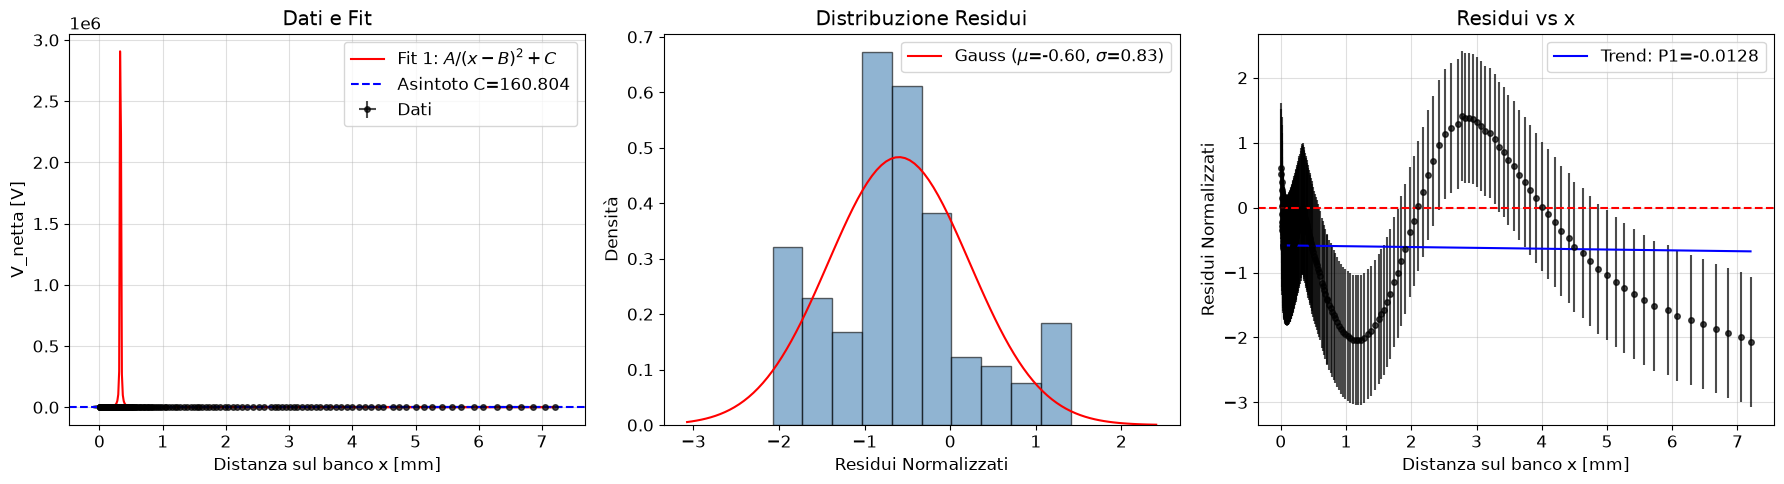

In [24]:

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Calcolo Varianza efficace finale per i residui
var_eff_1 = np.sqrt(ey**2 + (ex * deriv1(x, A_fit1, B_fit1))**2)
residui_norm_1 = (y - fitfunc1(x, A_fit1, B_fit1, C_fit1)) / var_eff_1

# GRAFICO 1: Curva di tensione e Fit 
ax1.errorbar(x, y, xerr=ex, yerr=ey, fmt='o', color='black', label='Dati', markersize=4, alpha=0.7)
x_plot = np.linspace(min(x), max(x), 500)
ax1.plot(x_plot, fitfunc1(x_plot, A_fit1, B_fit1, C_fit1), color='red', label='Fit 1: $A/(x-B)^2+C$')
ax1.axhline(C_fit1, color='blue', linestyle='--', label=f'Asintoto C={C_fit1:.3f}')
ax1.set_xlabel('Distanza sul banco x [mm]')
ax1.set_ylabel('V_netta [V]')
ax1.set_title('Dati e Fit')
ax1.legend()
ax1.grid(True, alpha=0.4)

#  GRAFICO 2: Istogramma dei Residui Normalizzati 
counts, bins, _ = ax2.hist(residui_norm_1, bins=10, density=True, alpha=0.6, color='steelblue', edgecolor='black')
# Fit Gaussiano dei residui
mu_res, std_res = norm.fit(residui_norm_1)
x_gauss = np.linspace(min(residui_norm_1)-1, max(residui_norm_1)+1, 100)
ax2.plot(x_gauss, norm.pdf(x_gauss, mu_res, std_res), color='red', label=f'Gauss ($\mu$={mu_res:.2f}, $\sigma$={std_res:.2f})')
ax2.set_xlabel('Residui Normalizzati')
ax2.set_ylabel('Densità')
ax2.set_title('Distribuzione Residui')
ax2.legend()

#  GRAFICO 3: Trend dei residui vs x 
ax3.errorbar(x, residui_norm_1, yerr=1.0, fmt='o', color='black', markersize=4, alpha=0.7)
ax3.axhline(0, color='red', linestyle='--')

# Fit lineare per cercare trend sistematici
def retta(x, P0, P1): return P0 + P1 * x
def chi2_trend(P0, P1): return np.sum(((residui_norm_1 - retta(x, P0, P1)) / 1.0)**2)
m_trend = Minuit(chi2_trend, P0=0.0, P1=0.0)
m_trend.errordef = Minuit.LEAST_SQUARES
m_trend.migrad()
P0_fit, P1_fit = m_trend.values["P0"], m_trend.values["P1"]

ax3.plot(x_plot, retta(x_plot, P0_fit, P1_fit), color='blue', label=f'Trend: P1={P1_fit:.4f}')
ax3.set_xlabel('Distanza sul banco x [mm]')
ax3.set_ylabel('Residui Normalizzati')
ax3.set_title('Residui vs x')
ax3.legend()
ax3.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### Fit 2:  $ \frac{A}{(x - B)^D} + C$


In [25]:

# Nuovo Modello con esponente D libero
def fitfunc2(x, A, B, C, D):
    return A / (x - B)**D + C

# Derivata rispetto a x
def deriv2(x, A, B, D):
    return -D * A / (x - B)**(D + 1)

def chi2_eff_2(A, B, C, D):
    sigma_eff_sq = ey**2 + (ex * deriv2(x, A, B, D))**2
    if np.any(x - B <= 0): # Evita basi negative per esponenti decimali
        return np.inf
    return np.sum(((y - fitfunc2(x, A, B, C, D))**2) / sigma_eff_sq)

# Passiamo i risultati del Fit 1 come parametri iniziali del Fit 2
m2 = Minuit(chi2_eff_2, A=A_fit1, B=B_fit1, C=C_fit1, D=2.0)
m2.errordef = Minuit.LEAST_SQUARES
m2.migrad()
m2.hesse()

print("=== RISULTATI FIT 2 (Esponente Libero) ===")
for p, v, e in zip(m2.parameters, m2.values, m2.errors):
    print(f"{p} = {v:.4f} ± {e:.4f}")
print(f"Chi2 / ndof = {m2.fval:.2f} / {len(x) - m2.nfit}")

# Valutazione di D
D_val = m2.values["D"]
D_err = m2.errors["D"]
t_val = abs(D_val - 2.0) / D_err
print(f"\nCompatibilità dell'esponente D con 2: |D - 2|/sigma = {t_val:.2f} sigma")
if t_val < 3:
    print("-> L'esponente è compatibile con 2. Legge dell'irradianza VERIFICATA.")
else:
    print("-> Attenzione: discrepanza oltre i 3 sigma.")

=== RISULTATI FIT 2 (Esponente Libero) ===
A = 131.5802 ± nan
B = 0.3331 ± nan
C = 160.8038 ± nan
D = 2.0000 ± nan
Chi2 / ndof = inf / 184

Compatibilità dell'esponente D con 2: |D - 2|/sigma = nan sigma
-> Attenzione: discrepanza oltre i 3 sigma.


/var/folders/s4/_bthznv52l9_j9tcmc5dxzkh0000gn/T/ipykernel_87759/4065733494.py:7: RuntimeWarning: invalid value encountered in power
  return -D * A / (x - B)**(D + 1)


### Verifica di B

In [26]:

# Dai dati delle costanti (aggiungere valori)
x_0 = 0.0          # Posizione di contatto [mm]
D_lampada = 40.0   # Diametro lampadina [mm]
prof_fotod = 1.0   # Profondità fotodiodo [mm]

# Errori sistematici
err_x0 = 0.5       # Errore su x_0 (esempio)
err_D_mezzi = 0.5  # Errore sul raggio della lampadina (calibro)
err_prof = 0.5     # Errore sulla profondità

# Calcolo del B atteso
B_atteso = x_0 - (D_lampada / 2) - prof_fotod

# Somma quadratica degli errori sistematici
sigma_B_atteso = np.sqrt(err_x0**2 + err_D_mezzi**2 + err_prof**2)

B_fit_val = m1.values["B"]
B_fit_err = m1.errors["B"]

# Verifica di compatibilità
diff_B = abs(B_fit_val - B_atteso)
sigma_tot_B = np.sqrt(B_fit_err**2 + sigma_B_atteso**2)
t_val_B = diff_B / sigma_tot_B

print(f"B_fit dal Modello = {B_fit_val:.2f} ± {B_fit_err:.2f} mm")
print(f"B_atteso (Sistematiche) = {B_atteso:.2f} ± {sigma_B_atteso:.2f} mm")
print(f"Compatibilità Offset: |ΔB|/sigma = {t_val_B:.2f} sigma")

B_fit dal Modello = 0.33 ± 0.03 mm
B_atteso (Sistematiche) = -21.00 ± 0.87 mm
Compatibilità Offset: |ΔB|/sigma = 24.62 sigma
